In [2]:
import warnings

import polars as pl
import seaborn as sns

warnings.filterwarnings('ignore')
%matplotlib inline
train = pl.read_csv("../../data/train.csv",infer_schema_length=None,null_values="NA")
train.head(3)

Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,…,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
i64,i64,str,i64,i64,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,str,str,str,str,str,i64,str,str,str,str,str,str,str,i64,str,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,str,i64,str,i64,str,str,i64,str,i64,i64,str,str,str,i64,i64,i64,i64,i64,i64,str,str,str,i64,i64,i64,str,str,i64
1,60,"""RL""",65,8450,"""Pave""",null,"""Reg""","""Lvl""","""AllPub""","""Inside""","""Gtl""","""CollgCr""","""Norm""","""Norm""","""1Fam""","""2Story""",7,5,2003,2003,"""Gable""","""CompShg""","""VinylSd""","""VinylSd""","""BrkFace""",196,"""Gd""","""TA""","""PConc""","""Gd""","""TA""","""No""","""GLQ""",706,"""Unf""",0,…,854,0,1710,1,0,2,1,3,1,"""Gd""",8,"""Typ""",0,null,"""Attchd""",2003,"""RFn""",2,548,"""TA""","""TA""","""Y""",0,61,0,0,0,0,null,null,null,0,2,2008,"""WD""","""Normal""",208500
2,20,"""RL""",80,9600,"""Pave""",null,"""Reg""","""Lvl""","""AllPub""","""FR2""","""Gtl""","""Veenker""","""Feedr""","""Norm""","""1Fam""","""1Story""",6,8,1976,1976,"""Gable""","""CompShg""","""MetalSd""","""MetalSd""","""None""",0,"""TA""","""TA""","""CBlock""","""Gd""","""TA""","""Gd""","""ALQ""",978,"""Unf""",0,…,0,0,1262,0,1,2,0,3,1,"""TA""",6,"""Typ""",1,"""TA""","""Attchd""",1976,"""RFn""",2,460,"""TA""","""TA""","""Y""",298,0,0,0,0,0,null,null,null,0,5,2007,"""WD""","""Normal""",181500
3,60,"""RL""",68,11250,"""Pave""",null,"""IR1""","""Lvl""","""AllPub""","""Inside""","""Gtl""","""CollgCr""","""Norm""","""Norm""","""1Fam""","""2Story""",7,5,2001,2002,"""Gable""","""CompShg""","""VinylSd""","""VinylSd""","""BrkFace""",162,"""Gd""","""TA""","""PConc""","""Gd""","""TA""","""Mn""","""GLQ""",486,"""Unf""",0,…,866,0,1786,1,0,2,1,3,1,"""Gd""",6,"""Typ""",1,"""TA""","""Attchd""",2001,"""RFn""",2,608,"""TA""","""TA""","""Y""",0,42,0,0,0,0,null,null,null,0,9,2008,"""WD""","""Normal""",223500


LandSlope null count: 0
LandSlope unique count: 3
String


column_0,column_1,column_2
str,str,str
"""Gtl""","""Mod""","""Sev"""
"""1382""","""65""","""13"""


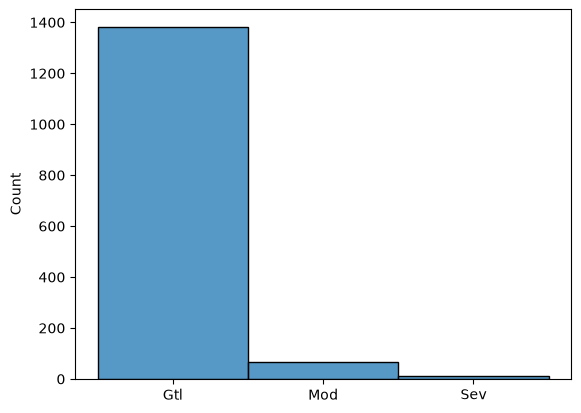

In [8]:
focus_feat = "LandSlope"
se = train[focus_feat]
# se = se.fill_null(np.nan)
print(f"{se.name} null count: {se.null_count()}")
print(f"{se.name} unique count: {se.n_unique()}")
sns.histplot(se) # type: ignore
print(se.dtype)
se.value_counts().sort(se.name).transpose()

<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

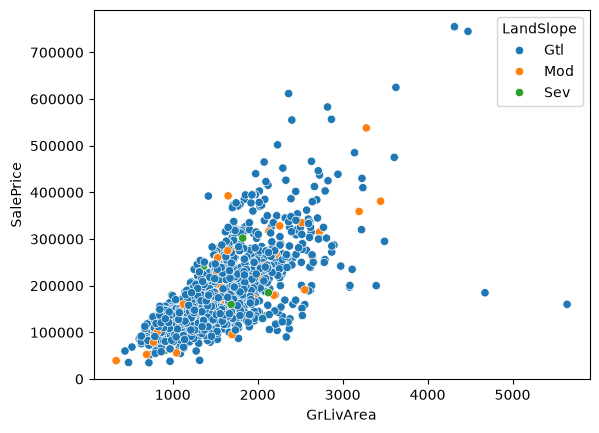

In [9]:
sns.scatterplot(data=train,x="GrLivArea",y="SalePrice",hue=focus_feat)

In [4]:
expensive = train \
    .group_by(focus_feat) \
    .agg(pl.mean("SalePrice")) \
    .filter(pl.col("SalePrice") > 300000) \
    .select(focus_feat).to_series().value_counts()
# sns.boxplot(x=se, y=train["SalePrice"])
expensive

LotConfig,count
str,u32


<Axes: xlabel='SalePrice', ylabel='LotConfig'>

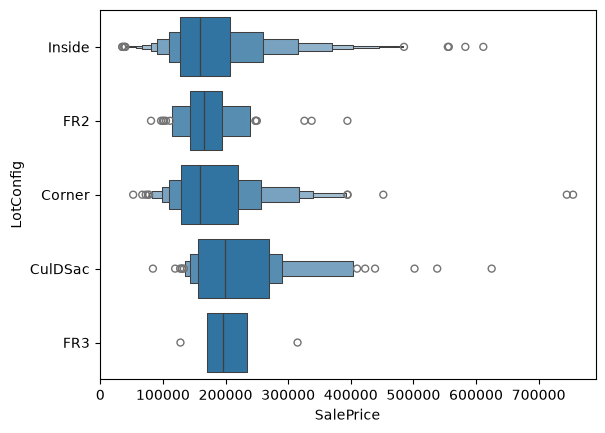

In [5]:
# sns.boxplot(x=se, y=train["SalePrice"])
sns.boxenplot(x=train["SalePrice"],y=se)

In [6]:
exp_add_feat = "hasCompositeExterior"

exp_add_feat_df = train.with_columns(
    pl.when(pl.col("Exterior1st") != pl.col("Exterior2nd"))
    .then(1)
    .otherwise(0)
    .alias(exp_add_feat))
exp_add_feat_df.filter(pl.col(exp_add_feat) == pl.lit(1)).sort(pl.col("SalePrice"),descending=True)

Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,…,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,hasCompositeExterior
i64,i64,str,i64,i64,str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,str,str,str,str,str,i64,str,str,str,str,str,str,str,i64,str,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,str,i64,str,i64,str,str,i64,str,i64,i64,str,str,str,i64,i64,i64,i64,i64,i64,str,str,str,i64,i64,i64,str,str,i64,i32
1183,60,"""RL""",160,15623,"""Pave""",null,"""IR1""","""Lvl""","""AllPub""","""Corner""","""Gtl""","""NoRidge""","""Norm""","""Norm""","""1Fam""","""2Story""",10,5,1996,1996,"""Hip""","""CompShg""","""Wd Sdng""","""ImStucc""","""None""",0,"""Gd""","""TA""","""PConc""","""Ex""","""TA""","""Av""","""GLQ""",2096,"""Unf""",0,…,0,4476,1,0,3,1,4,1,"""Ex""",10,"""Typ""",2,"""TA""","""Attchd""",1996,"""Fin""",3,813,"""TA""","""TA""","""Y""",171,78,0,0,0,555,"""Ex""","""MnPrv""",null,0,7,2007,"""WD""","""Abnorml""",745000,1
1047,60,"""RL""",85,16056,"""Pave""",null,"""IR1""","""Lvl""","""AllPub""","""Inside""","""Gtl""","""StoneBr""","""Norm""","""Norm""","""1Fam""","""2Story""",9,5,2005,2006,"""Hip""","""CompShg""","""CemntBd""","""CmentBd""","""Stone""",208,"""Gd""","""TA""","""PConc""","""Ex""","""TA""","""Av""","""GLQ""",240,"""Unf""",0,…,0,2868,0,0,3,1,4,1,"""Ex""",11,"""Typ""",1,"""Gd""","""BuiltIn""",2005,"""Fin""",3,716,"""TA""","""TA""","""Y""",214,108,0,0,0,0,null,null,null,0,7,2006,"""New""","""Partial""",556581,1
770,60,"""RL""",47,53504,"""Pave""",null,"""IR2""","""HLS""","""AllPub""","""CulDSac""","""Mod""","""StoneBr""","""Norm""","""Norm""","""1Fam""","""2Story""",8,5,2003,2003,"""Hip""","""CompShg""","""CemntBd""","""Wd Shng""","""BrkFace""",603,"""Ex""","""TA""","""PConc""","""Gd""","""TA""","""Gd""","""ALQ""",1416,"""Unf""",0,…,0,3279,1,0,3,1,4,1,"""Ex""",12,"""Mod""",1,"""Gd""","""BuiltIn""",2003,"""Fin""",3,841,"""TA""","""TA""","""Y""",503,36,0,0,210,0,null,null,null,0,6,2010,"""WD""","""Normal""",538000,1
592,60,"""RL""",97,13478,"""Pave""",null,"""IR1""","""Lvl""","""AllPub""","""Corner""","""Gtl""","""NridgHt""","""Norm""","""Norm""","""1Fam""","""2Story""",10,5,2008,2008,"""Gable""","""CompShg""","""CemntBd""","""CmentBd""","""Stone""",420,"""Ex""","""TA""","""PConc""","""Ex""","""TA""","""Gd""","""GLQ""",1338,"""Unf""",0,…,0,2296,1,0,2,1,3,1,"""Ex""",10,"""Typ""",1,"""Gd""","""BuiltIn""",2008,"""RFn""",3,842,"""TA""","""TA""","""Y""",382,274,0,0,0,0,null,null,null,0,6,2009,"""ConLI""","""Normal""",451950,1
350,60,"""RL""",56,20431,"""Pave""",null,"""IR2""","""Lvl""","""AllPub""","""Inside""","""Gtl""","""NridgHt""","""Norm""","""Norm""","""1Fam""","""2Story""",9,5,2005,2006,"""Hip""","""CompShg""","""CemntBd""","""CmentBd""","""BrkFace""",870,"""Ex""","""TA""","""PConc""","""Ex""","""TA""","""No""","""GLQ""",1410,"""Unf""",0,…,0,2728,1,0,2,1,4,1,"""Ex""",10,"""Typ""",2,"""Ex""","""Attchd""",2006,"""Fin""",3,706,"""TA""","""TA""","""Y""",0,0,0,0,0,0,null,null,null,0,4,2006,"""New""","""Partial""",437154,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
251,30,"""RL""",55,5350,"""Pave""",null,"""IR1""","""Lvl""","""AllPub""","""Inside""","""Gtl""","""BrkSide""","""Norm""","""Norm""","""1Fam""","""1Story""",3,2,1940,1966,"""Gable""","""C